In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/clean_nav_data.csv")
df.head()

,date,nav,fund_name,daily_return
0,2013-01-03,24.0092,Axis_Bluechip,0.000233
1,2013-01-04,24.0147,Axis_Bluechip,0.000229
2,2013-01-06,24.0258,Axis_Bluechip,0.000462
3,2013-01-07,24.0314,Axis_Bluechip,0.000233
4,2013-01-08,24.0369,Axis_Bluechip,0.000229


In [2]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True)
df = df.sort_values(["fund_name", "date"])

ValueError: unconverted data remains when parsing with format "%Y-%d-%m": "3". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
plt.figure(figsize=(12,6))

for fund in df["fund_name"].unique():
    temp = df[df["fund_name"] == fund]
    plt.plot(temp["date"], temp["nav"], label=fund)

plt.legend()
plt.title("NAV Trend of Mutual Funds")
plt.show()

In [ ]:
df["daily_return"] = df.groupby("fund_name")["nav"].pct_change()

sns.histplot(df["daily_return"].dropna(), bins=50)
plt.title("Daily Return Distribution")
plt.show()

In [ ]:
df.groupby("fund_name")["nav"].mean().plot(kind="bar")
plt.title("Average NAV by Fund")
plt.show()

In [3]:
df["date"] = pd.to_datetime(df["date"], errors="coerce", dayfirst=True)

In [4]:
df = df.dropna(subset=["date"])

In [5]:
df = df.sort_values(["fund_name", "date"])

In [6]:
df["daily_return"] = df.groupby("fund_name")["nav"].pct_change()
df = df.dropna()

In [7]:
df["date"] = pd.to_datetime(df["date"], errors="coerce", dayfirst=True)
df = df.dropna(subset=["date"])

In [8]:
df["daily_return"] = df.groupby("fund_name")["nav"].pct_change()
df = df.dropna(subset=["daily_return"])

In [9]:
df.head()
df["daily_return"].describe()

C:\Users\HP\mutual_fund_analysis\venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    7797.000000
mean             inf
std              NaN
min        -1.000000
25%        -0.010663
50%         0.007416
75%         0.033766
max              inf
Name: daily_return, dtype: float64

In [10]:
df = df[df["nav"] > 0]

In [11]:
df = df.sort_values(["fund_name", "date"])

In [12]:
df["daily_return"] = df.groupby("fund_name")["nav"].pct_change()

In [13]:
import numpy as np

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["daily_return"])

In [14]:
df["daily_return"].describe()

count    7790.000000
mean        0.156709
std         3.918003
min        -0.990715
25%        -0.010650
50%         0.007431
75%         0.033807
max       100.343612
Name: daily_return, dtype: float64

In [15]:
df = df[df["nav"] > 1]

In [16]:
df = df[(df["daily_return"] > -0.2) & (df["daily_return"] < 0.2)]

In [17]:
df["daily_return"].describe()

count    7558.000000
mean        0.009746
std         0.055098
min        -0.199419
25%        -0.006080
50%         0.007641
75%         0.034067
max         0.199645
Name: daily_return, dtype: float64

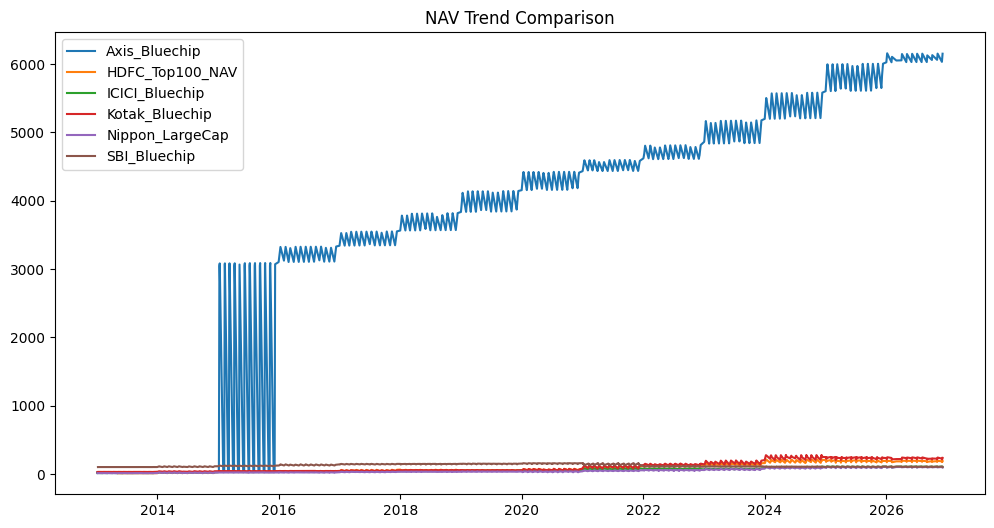

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for fund in df["fund_name"].unique():
    temp = df[df["fund_name"] == fund]
    plt.plot(temp["date"], temp["nav"], label=fund)

plt.legend()
plt.title("NAV Trend Comparison")
plt.show()

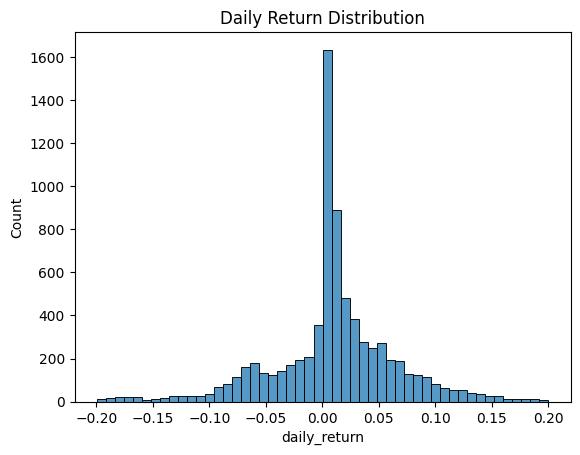

In [19]:
import seaborn as sns

sns.histplot(df["daily_return"], bins=50)
plt.title("Daily Return Distribution")
plt.show()

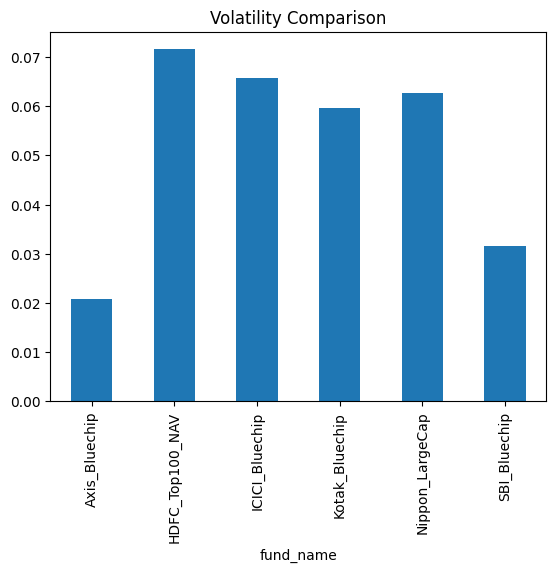

In [20]:
df.groupby("fund_name")["daily_return"].std().plot(kind="bar")
plt.title("Volatility Comparison")
plt.show()

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv("../data/processed/clean_nav_data.csv")

In [23]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["fund_name", "date"])

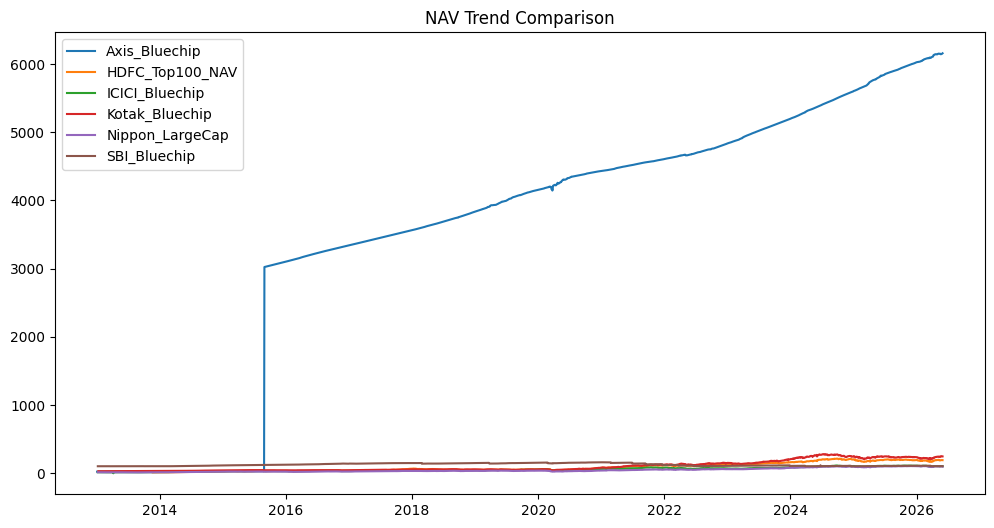

In [24]:
plt.figure(figsize=(12,6))

for fund in df["fund_name"].unique():
    temp = df[df["fund_name"] == fund]
    plt.plot(temp["date"], temp["nav"], label=fund)

plt.legend()
plt.title("NAV Trend Comparison")
plt.show()

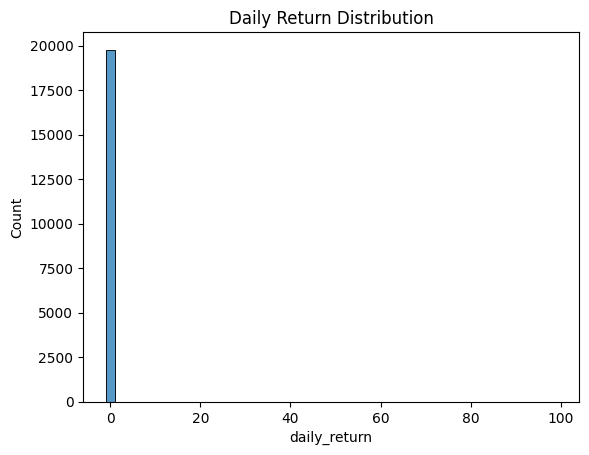

In [25]:
import seaborn as sns

sns.histplot(df["daily_return"], bins=50)
plt.title("Daily Return Distribution")
plt.show()

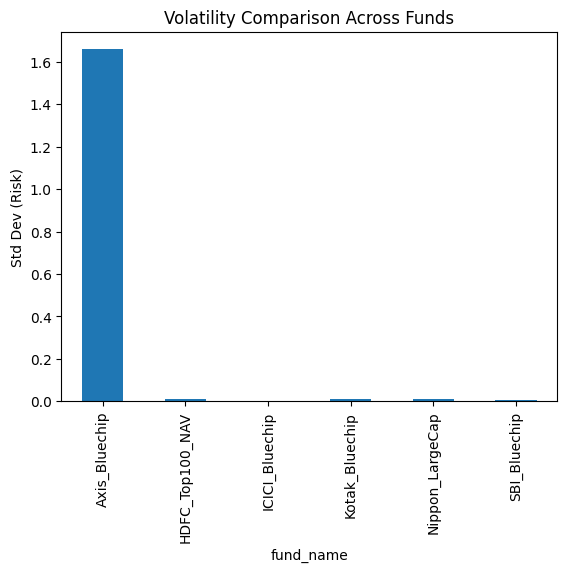

In [26]:
df.groupby("fund_name")["daily_return"].std().plot(kind="bar")
plt.title("Volatility Comparison Across Funds")
plt.ylabel("Std Dev (Risk)")
plt.show()